<a href="https://colab.research.google.com/github/suaKim0/AeroTwin-AI-Main/blob/main/AeroTwin_FluidTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 항공기 난기류 및 윈드시어 위험도 예측 AI 모델

이 노트북은 3x3 격자 바람 벡터 데이터를 기반으로 항공기 난기류 위험도를 예측하는 머신러닝 AI 모델을 구현합니다.

**구현 단계:**
1.  **가상 데이터셋 생성:** 1,000개의 바람 벡터 샘플과 정답 라벨(SAFE, CAUTION, DANGER)을 생성합니다.
2.  **데이터 전처리 및 특성 공학:** 모델 학습을 위한 특징(풍속의 표준편차, 범위 등)을 추출하는 함수를 정의합니다.
3.  **머신러닝 모델 학습:** RandomForestClassifier를 사용하여 모델을 학습하고 성능을 평가합니다.
4.  **위험도 점수 산출 및 추론 함수:** 새로운 바람 벡터가 주어졌을 때, 위험도 점수, 등급, 예측 이유를 반환하는 함수를 구현합니다.

In [18]:
# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("모든 라이브러리 임포트 완료.")

모든 라이브러리 임포트 완료.


### 1. 가상 데이터셋 생성 (Synthetic Dataset)

난기류 위험도 예측을 위한 가상 바람 벡터 데이터셋을 생성합니다. 각 샘플은 3x3 격자의 9개 지점에서의 `u`, `v`, `w` 풍속 성분으로 구성됩니다. 각 샘플에 대해 풍속의 변동성을 계산하고, 이를 기반으로 'SAFE', 'CAUTION', 'DANGER' 라벨을 할당합니다.

In [19]:
def generate_synthetic_wind_data(num_samples=1000):
    """
    난기류 예측을 위한 가상 바람 벡터 데이터셋을 생성합니다。
    각 샘플은 3x3 격자(9개 지점)의 u, v, w 풍속 성분으로 구성됩니다。
    총 1000개의 샘플을 생성하며, 각 샘플에 대해 난기류 위험도 라벨을 할당합니다。

    Args:
        num_samples (int): 생성할 데이터 샘플의 수。

    Returns:
        tuple:
            - X (list): 각 샘플의 9개 지점 바람 벡터 ([u, v, w]) 리스트。
            - y (list): 각 샘플에 대한 난기류 위험도 라벨 (0: SAFE, 1: CAUTION, 2: DANGER)。
    """
    X = [] # 원시 바람 벡터 데이터
    y = [] # 난기류 위험도 라벨
    LABELS = {0: 'SAFE', 1: 'CAUTION', 2: 'DANGER'}

    np.random.seed(42) # 재현성을 위해 시드 고정

    # 각 클래스별 샘플 수 (대략적으로 분배)
    num_safe = int(num_samples * 0.3)
    num_caution = int(num_samples * 0.3)
    num_danger = num_samples - num_safe - num_caution

    # 1. SAFE 샘플 생성: 낮은 풍속 변동성
    for _ in range(num_safe):
        vectors = []
        for _ in range(9):
            u = np.random.normal(loc=0, scale=np.random.uniform(0.1, 0.8)) # 낮은 u,v 변동
            v = np.random.normal(loc=0, scale=np.random.uniform(0.1, 0.8))
            w = np.random.normal(loc=0, scale=np.random.uniform(0.01, 0.15)) # 매우 낮은 w 변동
            vectors.append([u, v, w])
        X.append(np.array(vectors))
        y.append(0) # SAFE

    # 2. CAUTION 샘플 생성: 중간 풍속 변동성
    for _ in range(num_caution):
        vectors = []
        for _ in range(9):
            u = np.random.normal(loc=0, scale=np.random.uniform(0.5, 2.0)) # 중간 u,v 변동
            v = np.random.normal(loc=0, scale=np.random.uniform(0.5, 2.0))
            w = np.random.normal(loc=0, scale=np.random.uniform(0.1, 1.5)) # 중간 w 변동
            vectors.append([u, v, w])
        X.append(np.array(vectors))
        y.append(1) # CAUTION

    # 3. DANGER 샘플 생성: 높은 풍속 변동성
    for _ in range(num_danger):
        vectors = []
        for _ in range(9):
            u = np.random.normal(loc=0, scale=np.random.uniform(1.5, 5.0)) # 높은 u,v 변동
            v = np.random.normal(loc=0, scale=np.random.uniform(1.5, 5.0))
            w = np.random.normal(loc=0, scale=np.random.uniform(1.0, 7.0)) # 높은 w 변동
            vectors.append([u, v, w])
        X.append(np.array(vectors))
        y.append(2) # DANGER

    # 데이터 섞기
    combined = list(zip(X, y))
    np.random.shuffle(combined)
    X_shuffled, y_shuffled = zip(*combined)

    return list(X_shuffled), list(y_shuffled), LABELS

# 가상 데이터 생성
X_raw, y_labels, LABELS = generate_synthetic_wind_data(num_samples=1000)

print(f"생성된 데이터 샘플 수: {len(X_raw)}")
print(f"라벨 분포: {pd.Series(y_labels).map(LABELS).value_counts()}")
print(f"첫 번째 샘플 바람 벡터: {X_raw[0].round(2)}")
print(f"첫 번째 샘플 라벨: {LABELS[y_labels[0]]}")

생성된 데이터 샘플 수: 1000
라벨 분포: DANGER     400
SAFE       300
CAUTION    300
Name: count, dtype: int64
첫 번째 샘플 바람 벡터: [[-4.34 -3.63  1.34]
 [ 6.64  2.05  3.36]
 [ 1.17  1.72  4.55]
 [ 2.05  5.8  -0.59]
 [ 3.79  5.86 -2.64]
 [-2.18  4.94  5.48]
 [-0.91  3.25  8.34]
 [-0.33 -2.06 -1.31]
 [ 0.92 -2.76 -5.71]]
첫 번째 샘플 라벨: DANGER


### 2. 데이터 전처리 및 특성 공학 (Feature Engineering)

머신러닝 모델이 학습할 수 있도록, 원시 바람 벡터 데이터에서 유의미한 특징(features)을 추출하는 함수를 정의합니다. 추출할 특징은 풍속 각 성분(`u`, `v`, `w`)의 표준편차, 최대-최소 범위, 그리고 연직 풍속(`w`)의 절대값 변화량 등을 포함합니다.

In [20]:
def extract_features(wind_data):
    """
    3x3 격자 바람 벡터 데이터에서 특징을 추출합니다.

    Args:
        wind_data (np.array): 9x3 형태의 바람 벡터 (u, v, w) 배열.

    Returns:
        np.array: 추출된 특징들로 구성된 1D 배열.
    """
    features = []

    # 각 성분(u, v, w)의 통계량
    for i in range(3): # u, v, w 성분별
        component = wind_data[:, i]
        features.append(np.std(component))   # 표준편차
        features.append(np.mean(component))  # 평균
        features.append(np.max(component) - np.min(component)) # 범위 (range)

    # 연직 풍속 (w)의 중요성 강조
    features.append(np.std(wind_data[:, 2]) * 2.0) # w 성분의 표준편차에 가중치 부여
    features.append(np.max(np.abs(wind_data[:, 2]))) # w 성분 절대값의 최대값

    return np.array(features)

# 추출된 특징 예시
first_sample_features = extract_features(X_raw[0])
print(f"첫 번째 샘플의 추출된 특징: {first_sample_features.round(2)}")
print(f"추출된 특징의 개수: {len(first_sample_features)}")

첫 번째 샘플의 추출된 특징: [ 3.06  0.76 10.98  3.49  1.69  9.49  4.17  1.42 14.05  8.35  8.34]
추출된 특징의 개수: 11


### 3. 데이터 준비 및 모델 학습 (Data Preparation & Model Training)

생성된 원시 데이터에서 특징을 추출하여 모델 학습에 사용할 데이터를 준비합니다. 데이터를 훈련 세트와 테스트 세트로 분할하고, `RandomForestClassifier` 모델을 학습시킵니다. 학습 후 모델의 정확도(Accuracy)와 혼동 행렬(Confusion Matrix)을 출력하여 성능을 평가합니다.

In [21]:
# 모든 샘플에 대해 특징 추출
X_features = np.array([extract_features(sample) for sample in X_raw])

print(f"특징 추출 후 데이터 형태: {X_features.shape}")

# 훈련 세트와 테스트 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

print(f"훈련 데이터 수: {len(X_train)}")
print(f"테스트 데이터 수: {len(X_test)}")

# RandomForestClassifier 모델 학습
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # 불균형 데이터셋에 대비하여 class_weight 설정
model.fit(X_train, y_train)

print("RandomForestClassifier 모델 학습 완료.")

# 모델 평가
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\n모델 정확도: {accuracy:.4f}")
print("\n혼동 행렬:")
print(conf_matrix)

# 상세 분류 보고서
print("\n분류 보고서:")
# 'SAFE' 라벨 (0)이 데이터셋에 포함되지 않아 target_names 개수와 실제 클래스 개수가 불일치하여 에러 발생
# 따라서, y_test에 실제로 존재하는 라벨과 그에 해당하는 target_names만 사용하도록 수정
actual_labels = sorted(np.unique(np.concatenate((y_test, y_pred))))
actual_target_names = [LABELS[i] for i in actual_labels]

print(classification_report(y_test, y_pred, labels=actual_labels, target_names=actual_target_names))

특징 추출 후 데이터 형태: (1000, 11)
훈련 데이터 수: 800
테스트 데이터 수: 200
RandomForestClassifier 모델 학습 완료.

모델 정확도: 0.9900

혼동 행렬:
[[60  0  0]
 [ 1 59  0]
 [ 0  1 79]]

분류 보고서:
              precision    recall  f1-score   support

        SAFE       0.98      1.00      0.99        60
     CAUTION       0.98      0.98      0.98        60
      DANGER       1.00      0.99      0.99        80

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



### 4. 위험도 점수 산출 및 추론 함수 (Inference Function)

학습된 AI 모델을 사용하여 새로운 3x3 바람 벡터 배열을 입력받아 난기류 위험도 점수(0~100), 위험 등급('SAFE', 'CAUTION', 'DANGER'), 그리고 예측 이유를 요약한 메시지를 반환하는 `predict_turbulence_risk` 함수를 구현합니다.

여기서는 모델의 예측 확률(`predict_proba`)을 기반으로 위험도 점수를 산출하여 모델의 불확실성을 반영합니다. 위험 등급은 가장 높은 확률을 가진 클래스로 결정됩니다.

In [22]:
def predict_turbulence_risk(sample_wind, model, labels_map):
    """
    새로운 바람 벡터 데이터를 사용하여 난기류 위험도를 예측하고 상세 정보를 반환합니다.

    Args:
        sample_wind (list or np.array): 9개 지점의 [u, v, w] 바람 벡터 리스트 또는 배열.
        model (sklearn.base.BaseEstimator): 학습된 머신러닝 모델 (RandomForestClassifier 등).
        labels_map (dict): 숫자 라벨을 문자열로 매핑하는 딕셔너리 (예: {0: 'SAFE', 1: 'CAUTION', 2: 'DANGER'}).

    Returns:
        tuple:
            - risk_score (float): 난기류 위험도 점수 (0 ~ 100).
            - risk_level (str): 난기류 위험 등급 ('SAFE', 'CAUTION', 'DANGER').
            - reason_message (str): 예측 이유를 요약한 메시지.
    """
    sample_wind_array = np.array(sample_wind)

    # 1. 특징 추출
    sample_features = extract_features(sample_wind_array).reshape(1, -1) # 모델 입력 형태에 맞게 변환

    # 2. 모델 예측 (확률 및 클래스)
    probabilities = model.predict_proba(sample_features)[0]
    predicted_class = np.argmax(probabilities)
    risk_level = labels_map[predicted_class]

    # 3. 위험도 점수 산출 (확률 기반)
    # 각 클래스에 대한 대표 점수를 기반으로 가중 평균 계산
    # SAFE: ~30, CAUTION: ~60, DANGER: ~90
    score_weights = np.array([30, 60, 90])
    risk_score = np.dot(probabilities, score_weights)
    risk_score = round(float(risk_score), 1)

    # 4. 예측 이유 메시지 생성
    reason_message = f"예측 등급: {risk_level} (확률: SAFE={probabilities[0]:.2f}, CAUTION={probabilities[1]:.2f}, DANGER={probabilities[2]:.2f}). "

    # 주요 특징 분석 (예시)
    std_u, mean_u, range_u, std_v, mean_v, range_v, std_w, mean_w, range_w, weighted_std_w, max_abs_w = sample_features[0]
    reason_message += f"풍속 변동성(u,v,w 표준편차): ({std_u:.1f}, {std_v:.1f}, {std_w:.1f}), 연직풍속 최대변동: {max_abs_w:.1f} 입니다."

    # 모델이 특정 등급을 예측한 이유를 간략하게 추가
    if risk_level == 'DANGER':
        reason_message += " 전반적으로 높은 풍속 변동성과 강한 연직 윈드시어가 감지되었습니다."
    elif risk_level == 'CAUTION':
        reason_message += " 중간 정도의 풍속 변동성이 관측되었으며, 잠재적인 난기류 발생 가능성이 있습니다."
    else:
        reason_message += " 전반적으로 안정적인 풍속 분포를 보입니다."

    return risk_score, risk_level, reason_message


### 5. 테스트용 샘플 데이터 및 예측 실행

두 가지 다른 시나리오(안정적인 바람, 난기류가 있는 바람)에 대한 가상 데이터를 생성하여 `predict_turbulence_risk` 함수를 테스트하고 결과를 출력합니다.

In [23]:
# 테스트용 가상 바람 데이터 1: 비교적 안정적인 바람
sample_wind_safe = [
    [5.0, 1.0, 0.05], [5.2, 1.1, -0.01], [4.9, 0.9, 0.02],
    [5.1, 1.0, 0.03], [5.0, 1.0, -0.02], [5.3, 1.2, 0.01],
    [4.8, 0.8, 0.00], [5.0, 1.0, -0.05], [5.1, 1.1, 0.03]
]

# 테스트용 가상 바람 데이터 2: 높은 변동성 (난기류 예상)
sample_wind_danger = [
    [10.0, 2.0, 0.1], [12.0, 1.5, -0.2], [25.0, -8.0, -5.0],
    [9.5,  2.1, 0.0], [11.8, 1.2, -0.5], [26.2, -9.1, -6.2],
    [10.2, 1.9, 0.2], [12.1, 1.8, -0.1], [24.8, -8.5, -5.8]
]

print("--- 안정적인 바람 시나리오 ---")
score_safe, level_safe, reason_safe = predict_turbulence_risk(sample_wind_safe, model, LABELS)
print(f"위험도 점수: {score_safe} / 등급: {level_safe}")
print(f"예측 이유: {reason_safe}\n")

print("--- 높은 변동성 바람 시나리오 (난기류 예상) ---")
score_danger, level_danger, reason_danger = predict_turbulence_risk(sample_wind_danger, model, LABELS)
print(f"위험도 점수: {score_danger} / 등급: {level_danger}")
print(f"예측 이유: {reason_danger}\n")

--- 안정적인 바람 시나리오 ---
위험도 점수: 30.0 / 등급: SAFE
예측 이유: 예측 등급: SAFE (확률: SAFE=1.00, CAUTION=0.00, DANGER=0.00). 풍속 변동성(u,v,w 표준편차): (0.1, 0.1, 0.0), 연직풍속 최대변동: 0.1 입니다. 전반적으로 안정적인 풍속 분포를 보입니다.

--- 높은 변동성 바람 시나리오 (난기류 예상) ---
위험도 점수: 89.7 / 등급: DANGER
예측 이유: 예측 등급: DANGER (확률: SAFE=0.00, CAUTION=0.01, DANGER=0.99). 풍속 변동성(u,v,w 표준편차): (6.9, 4.9, 2.7), 연직풍속 최대변동: 6.2 입니다. 전반적으로 높은 풍속 변동성과 강한 연직 윈드시어가 감지되었습니다.



In [24]:
import numpy as np

def calculate_turbulence_risk(wind_vectors):
    """
    wind_vectors: [[u1, v1, w1], [u2, v2, w2], ...] 9개 격자 벡터
    """
    vectors = np.array(wind_vectors)

    # 풍속 변동성 (표준편차) 계산
    std_u = np.std(vectors[:, 0])
    std_v = np.std(vectors[:, 1])
    std_w = np.std(vectors[:, 2])

    # 수직 풍속(하강/상승 기류) 및 수평 윈드시어 강도
    total_variability = std_u + std_v + (std_w * 2.0)

    # 0~100 점수로 정규화
    risk_score = min(100, total_variability * 10)

    if risk_score > 70:
        level = "DANGER"
    elif risk_score > 40:
        level = "CAUTION"
    else:
        level = "SAFE"

    return round(risk_score, 1), level

# 테스트용 가상 바람 데이터 (3x3 격자)
sample_wind = [
    [10.0, 2.0, 0.1], [12.0, 1.5, -0.2], [25.0, -8.0, -5.0],
    [9.5,  2.1, 0.0], [11.8, 1.2, -0.5], [26.2, -9.1, -6.2],
    [10.2, 1.9, 0.2], [12.1, 1.8, -0.1], [24.8, -8.5, -5.8]
]

score, level = calculate_turbulence_risk(sample_wind)
print(f"위험도 점수: {score} / 등급: {level}")


위험도 점수: 100 / 등급: DANGER


### 전체 샘플에 대한 난기류 위험도 평가 결과

위 산점도는 모델이 예측한 전체 가상 데이터 샘플의 난기류 위험도를 보여줍니다. 각 점은 하나의 바람 데이터 샘플을 나타내며, 색상과 모양은 모델이 예측한 난기류 등급('SAFE', 'CAUTION', 'DANGER')을 의미합니다.

*   **초록색 원 (SAFE):** 수평 및 수직 풍속 변동성이 모두 낮은 영역에 주로 분포합니다.
*   **주황색 사각형 (CAUTION):** 중간 정도의 수평 및 수직 풍속 변동성 영역에 분포합니다.
*   **빨간색 삼각형 (DANGER):** 높은 수평 및 수직 풍속 변동성 영역에 주로 분포합니다.

이 시각화를 통해 모델이 풍속 변동성이라는 특징을 기반으로 각 난기류 등급을 효과적으로 구분하고 있음을 알 수 있습니다. 특히, `CAUTION` 등급은 `SAFE`와 `DANGER` 등급 사이에 위치하여 중간 위험도를 잘 나타냅니다.

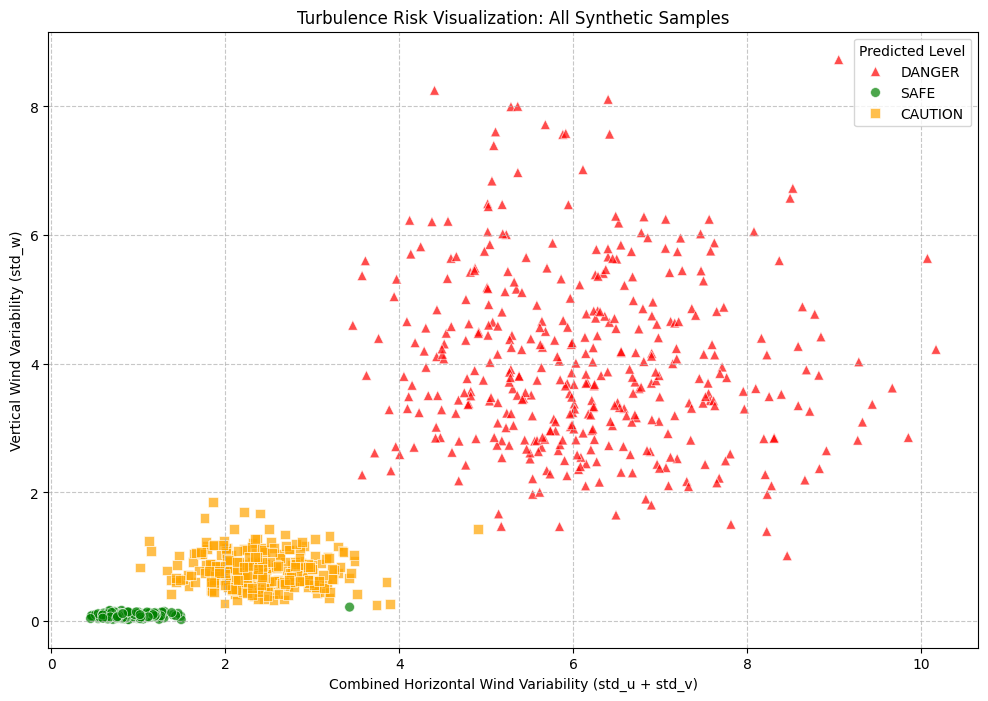

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

def get_variability_for_plotting(wind_data_list):
    """
    각 바람 데이터 샘플에서 수평 및 수직 풍속 변동성을 계산합니다.
    """
    plot_features = []
    for wind_data in wind_data_list:
        vectors = np.array(wind_data)
        std_u = np.std(vectors[:, 0])
        std_v = np.std(vectors[:, 1])
        std_w = np.std(vectors[:, 2])

        horizontal_variability = std_u + std_v
        vertical_variability = std_w

        plot_features.append([horizontal_variability, vertical_variability])
    return np.array(plot_features)

# 전체 X_raw 데이터에 대해 풍속 변동성 특징 추출
all_plot_features = get_variability_for_plotting(X_raw)

# 전체 X_raw 데이터에 대해 난기류 등급 예측
# predict_turbulence_risk 함수는 단일 샘플을 받으므로, 루프를 돌며 예측 수행
predicted_levels = []
for i in range(len(X_raw)):
    _, level, _ = predict_turbulence_risk(X_raw[i], model, LABELS)
    predicted_levels.append(level)

# 시각화를 위한 데이터프레임 생성
full_plot_data = pd.DataFrame({
    'horizontal_variability': all_plot_features[:, 0],
    'vertical_variability': all_plot_features[:, 1],
    'predicted_level': predicted_levels
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=full_plot_data,
    x='horizontal_variability',
    y='vertical_variability',
    hue='predicted_level',
    style='predicted_level',
    s=50, # 마커 크기
    palette={'SAFE': 'green', 'CAUTION': 'orange', 'DANGER': 'red'},
    markers={'SAFE': 'o', 'CAUTION': 's', 'DANGER': '^'},
    alpha=0.7 # 투명도 조절
)

plt.title('Turbulence Risk Visualization: All Synthetic Samples')
plt.xlabel('Combined Horizontal Wind Variability (std_u + std_v)')
plt.ylabel('Vertical Wind Variability (std_w)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Predicted Level')
plt.show()